<a href="https://colab.research.google.com/github/hishamtaha-ai/AI-Investment-Advisor-Platform/blob/main/stock_price_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U transformers

## Local Inference on GPU
Model page: https://huggingface.co/suryaR-15/lstm-stock-price-predictor

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/suryaR-15/lstm-stock-price-predictor)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# pip install -U transformers accelerate
# Load model directly
from transformers import AutoModel
model = AutoModel.from_pretrained("suryaR-15/lstm-stock-price-predictor", device_map="auto")

Saving SWDY.csv to SWDY.csv
الأعمدة الموجودة: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Capital Gains']


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2021-01-03 00:00:00+02:00,8.931844,9.013787,8.831691,8.940948,797851,0.0,0.0,0.0
1,2021-01-04 00:00:00+02:00,8.940950,8.922740,8.749748,8.831692,932801,0.0,0.0,0.0
2,2021-01-05 00:00:00+02:00,8.831690,9.332456,8.749747,9.104836,3891759,0.0,0.0,0.0
3,2021-01-06 00:00:00+02:00,9.104836,9.469029,9.132151,9.314247,2314344,0.0,0.0,0.0
4,2021-01-10 00:00:00+02:00,9.314247,9.642022,9.296038,9.496345,3282810,0.0,0.0,0.0


/tmp/ipykernel_666/1707024833.py:56: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data["Date"] = pd.to_datetime(


عدد الجلسات: 1234
الفترة: 2021-01-03 00:00:00+02:00 إلى 2026-02-04 00:00:00+02:00
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0238 - val_loss: 0.6060
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0178 - val_loss: 0.1003
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0065 - val_loss: 0.1720
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0024 - val_loss: 0.1563
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0027 - val_loss: 0.1500
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0032 - val_loss: 0.1447
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0031 - val_loss: 0.1014
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0060 - val_loss: 0.1080
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0116 - val_loss: 0.0738
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0095 - val_loss: 0.0432
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - l

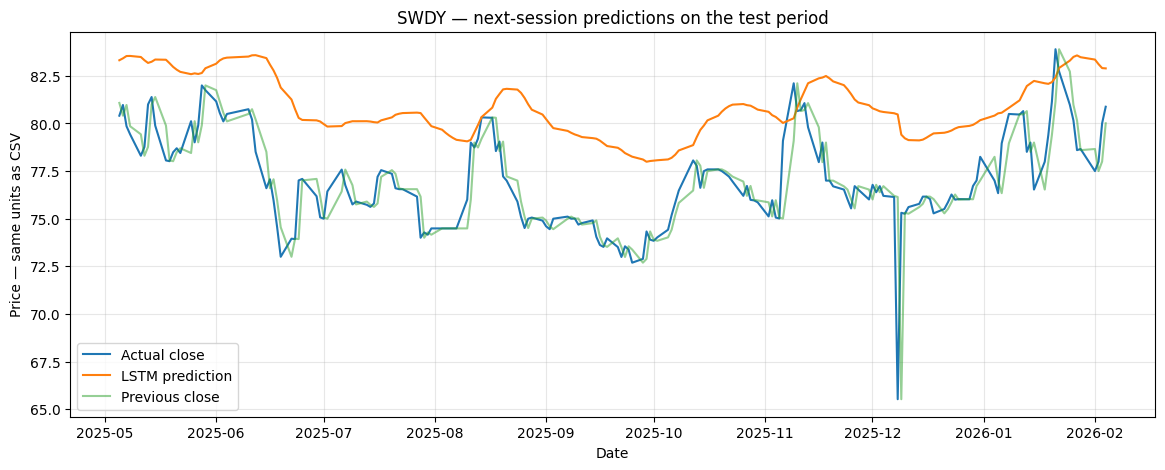


آخر سعر إغلاق في الملف: 80.880
توقع إغلاق جلسة التداول التالية: 82.980

تم حفظ SWDY_LSTM.keras وSWDY_preprocessing.joblib


In [2]:
import io
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#simply for random guess
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#share csv
uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.columns = df.columns.str.strip()

print("الأعمدة الموجودة:", df.columns.tolist())
display(df.head())

# dates
DATE_COLUMN = None
PRICE_COLUMN = None
DAY_FIRST = False

def find_column(options):
    columns = {str(c).lower(): c for c in df.columns}
    return next((columns[o.lower()] for o in options
                 if o.lower() in columns), None)

date_col = DATE_COLUMN or find_column(
    ["Date", "Datetime", "Timestamp", "التاريخ"]
)
price_col = PRICE_COLUMN or find_column(
    ["Close", "Price", "Closing Price", "الإغلاق", "اغلاق"]
)

if date_col is None or price_col is None:
    raise ValueError(
        "حدد DATE_COLUMN وPRICE_COLUMN حسب أسماء الأعمدة المطبوعة فوق، "
        "ثم شغّل الخلية مرة أخرى."
    )

# data cleaning
data = df[[date_col, price_col]].copy()
data.columns = ["Date", "Close"]

data["Date"] = pd.to_datetime(
    data["Date"], errors="coerce", dayfirst=DAY_FIRST
)
#support price
data["Close"] = pd.to_numeric(
    data["Close"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

data = (
    data.dropna()
        .sort_values("Date")
        .drop_duplicates("Date", keep="last")
        .reset_index(drop=True)
)

if len(data) < 200:
    raise ValueError(
        f"عدد الصفوف الصالحة {len(data)} فقط. "
        "استخدم على الأقل 200 جلسة، ويفضل بيانات أكثر."
    )

print(f"عدد الجلسات: {len(data)}")
print(f"الفترة: {data['Date'].min()} إلى {data['Date'].max()}")

# time handling
WINDOW = 30  # use last 30 set
prices = data[["Close"]].to_numpy(dtype=np.float32)

train_end = int(len(prices) * 0.70)
val_end = int(len(prices) * 0.85)
#Normalization for test & traing data
scaler = MinMaxScaler()
scaler.fit(prices[:train_end])
scaled = scaler.transform(prices)

X, y, target_indices = [], [], []

for i in range(WINDOW, len(scaled)):
    X.append(scaled[i-WINDOW:i])
    y.append(scaled[i])
    target_indices.append(i)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
target_indices = np.array(target_indices)

train_mask = target_indices < train_end
val_mask = (target_indices >= train_end) & (target_indices < val_end)
test_mask = target_indices >= val_end

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# create model
model = Sequential([
    Input(shape=(WINDOW, 1)),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    shuffle=False,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

# result in time rang
predicted = scaler.inverse_transform(
    model.predict(X_test, verbose=0)
).ravel()

actual = scaler.inverse_transform(y_test).ravel()

# Comparison between test time & traing data
baseline = scaler.inverse_transform(
    X_test[:, -1, :]
).ravel()

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
baseline_mae = mean_absolute_error(actual, baseline)

print(f"\nModel MAE: {mae:.3f}")
print(f"Model RMSE: {rmse:.3f}")
print(f"Baseline MAE: {baseline_mae:.3f}")
print("الأقل أفضل. قارن النموذج بتوقع آخر سعر معروف.")

test_dates = data["Date"].iloc[target_indices[test_mask]]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, actual, label="Actual close")
plt.plot(test_dates, predicted, label="LSTM prediction")
plt.plot(test_dates, baseline, label="Previous close", alpha=0.5)
plt.title("SWDY — next-session predictions on the test period")
plt.xlabel("Date")
plt.ylabel("Price — same units as CSV")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
#last set
last_window = scaled[-WINDOW:].reshape(1, WINDOW, 1)
next_scaled = model.predict(last_window, verbose=0)
next_price = scaler.inverse_transform(next_scaled)[0, 0]

print(f"\nآخر سعر إغلاق في الملف: {prices[-1, 0]:.3f}")
print(f"توقع إغلاق جلسة التداول التالية: {next_price:.3f}")
#save
import joblib

model.save("SWDY_LSTM.keras")
joblib.dump(
    {
        "scaler": scaler,
        "window": WINDOW,
        "date_column": date_col,
        "price_column": price_col
    },
    "SWDY_preprocessing.joblib"
)

print("\nتم حفظ SWDY_LSTM.keras وSWDY_preprocessing.joblib")

التدريب: 2021-01-03 إلى 2025-12-31 — 1212 جلسة
الاختبار: 2026-01-04 إلى 2026-02-04 — 22 جلسة

أفضل alpha حسب التوقع المتتابع في 2025: 1000
Model MAE: 1.751
Model RMSE: 2.053
Fixed-price Baseline MAE: 1.759
النموذج تفوق على تثبيت آخر إغلاق في الفترة المتاحة.


,Date,Actual,Predicted,Baseline,Absolute_Error
0,2026-01-04,77.000000,78.447916,78.25,1.447916
1,2026-01-05,76.339996,78.640171,78.25,2.300175
2,2026-01-06,78.959999,78.724205,78.25,0.235794
3,2026-01-08,80.500000,78.893101,78.25,1.606899
4,2026-01-11,80.470001,79.063987,78.25,1.406014
5,2026-01-12,80.650002,79.248083,78.25,1.401919
6,2026-01-13,78.510002,79.420567,78.25,0.910565
7,2026-01-14,79.000000,79.579926,78.25,0.579926
8,2026-01-15,76.529999,79.711810,78.25,3.181811
9,2026-01-18,77.989998,79.857121,78.25,1.867123


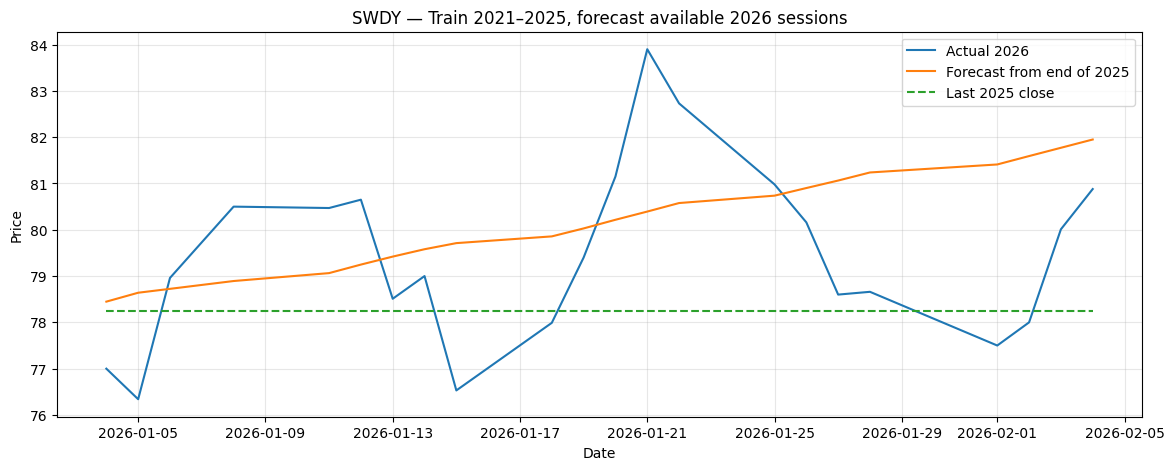


تم حفظ:
SWDY_Ridge_2021_2025.joblib
SWDY_predictions_2026.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# setup data file
prices_df = df[["Date", "Close"]].copy()

prices_df["Date"] = pd.to_datetime(
    prices_df["Date"].astype(str).str[:10],
    errors="coerce"
)
prices_df["Close"] = pd.to_numeric(
    prices_df["Close"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

prices_df = (
    prices_df.dropna()
             .sort_values("Date")
             .drop_duplicates("Date", keep="last")
             .reset_index(drop=True)
)

if (prices_df["Close"] <= 0).any():
    raise ValueError("يوجد سعر صفر أو سالب؛ راجع البيانات.")

train_data = prices_df[
    (prices_df["Date"] >= "2021-01-01") &
    (prices_df["Date"] < "2026-01-01")
].copy()

test_data = prices_df[
    (prices_df["Date"] >= "2026-01-01") &
    (prices_df["Date"] < "2027-01-01")
].copy()

WINDOW = 20

if len(train_data) < 100 or test_data.empty:
    raise ValueError("بيانات التدريب غير كافية أو بيانات 2026 غير موجودة.")

print(
    f"التدريب: {train_data['Date'].min().date()} إلى "
    f"{train_data['Date'].max().date()} — {len(train_data)} جلسة"
)
print(
    f"الاختبار: {test_data['Date'].min().date()} إلى "
    f"{test_data['Date'].max().date()} — {len(test_data)} جلسة"
)

# build data for test
train_prices = train_data["Close"].to_numpy(dtype=float)
returns = train_prices[1:] / train_prices[:-1] - 1

X, y, target_indices = [], [], []

for i in range(WINDOW, len(returns)):
    X.append(returns[i-WINDOW:i])
    y.append(returns[i])
    target_indices.append(i + 1)

X = np.asarray(X)
y = np.asarray(y)
target_indices = np.asarray(target_indices)

# olny see data on 2025
target_dates = train_data["Date"].to_numpy()[target_indices]
fit_mask = target_dates < np.datetime64("2025-01-01")
val_mask = target_dates >= np.datetime64("2025-01-01")

if not fit_mask.any() or not val_mask.any():
    raise ValueError("نحتاج بيانات قبل 2025 وداخل 2025 لاختيار الإعدادات.")

# cjeck result 2026
def recursive_forecast(model, initial_returns, initial_price, steps):
    history = list(initial_returns[-WINDOW:])
    price = float(initial_price)
    predictions = []

    for _ in range(steps):
        predicted_return = float(
            model.predict(
                np.asarray(history[-WINDOW:]).reshape(1, -1)
            )[0]
        )

        if not np.isfinite(predicted_return) or predicted_return <= -1:
            raise ValueError("النموذج أنتج نسبة تغير غير صالحة.")

        price *= 1 + predicted_return

        if not np.isfinite(price):
            raise ValueError("التوقع المتتابع أصبح غير صالح.")

        predictions.append(price)
        history.append(predicted_return)

    return np.asarray(predictions)

first_val_index = target_indices[val_mask][0]
actual_val = train_prices[target_indices[val_mask]]

best_alpha = None
best_mae = float("inf")

for alpha in [0.1, 1, 10, 100, 1000]:
    candidate = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha)
    )
    candidate.fit(X[fit_mask], y[fit_mask])

    try:
        val_predictions = recursive_forecast(
            candidate,
            returns[:first_val_index - 1],
            train_prices[first_val_index - 1],
            len(actual_val)
        )
        error = mean_absolute_error(actual_val, val_predictions)
    except ValueError:
        error = float("inf")

    if error < best_mae:
        best_mae = error
        best_alpha = alpha

if best_alpha is None:
    raise ValueError("كل الإعدادات أنتجت توقعات غير صالحة.")

print(f"\nأفضل alpha حسب التوقع المتتابع في 2025: {best_alpha}")

# train on data from 2021 to 2025
model_2026 = make_pipeline(
    StandardScaler(),
    Ridge(alpha=best_alpha)
)
model_2026.fit(X, y)

#test data 2026
predicted = recursive_forecast(
    model_2026,
    returns,
    train_prices[-1],
    len(test_data)
)

# 5)Comparison between result & real data
actual = test_data["Close"].to_numpy(dtype=float)
baseline = np.full(len(actual), train_prices[-1])

model_mae = mean_absolute_error(actual, predicted)
baseline_mae = mean_absolute_error(actual, baseline)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print(f"Model MAE: {model_mae:.3f}")
print(f"Model RMSE: {rmse:.3f}")
print(f"Fixed-price Baseline MAE: {baseline_mae:.3f}")

if model_mae < baseline_mae:
    print("النموذج تفوق على تثبيت آخر إغلاق في الفترة المتاحة.")
else:
    print("تثبيت آخر إغلاق أفضل في الفترة المتاحة.")

results = pd.DataFrame({
    "Date": test_data["Date"].to_numpy(),
    "Actual": actual,
    "Predicted": predicted,
    "Baseline": baseline
})
results["Absolute_Error"] = abs(
    results["Actual"] - results["Predicted"]
)

display(results)

plt.figure(figsize=(14, 5))
plt.plot(results["Date"], actual, label="Actual 2026")
plt.plot(results["Date"], predicted, label="Forecast from end of 2025")
plt.plot(results["Date"], baseline, "--", label="Last 2025 close")
plt.title("SWDY — Train 2021–2025, forecast available 2026 sessions")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# save model
import joblib

joblib.dump(
    {
        "model": model_2026,
        "window": WINDOW,
        "last_returns": returns[-WINDOW:],
        "last_price": float(train_prices[-1]),
        "training_end": str(train_data["Date"].max().date())
    },
    "SWDY_Ridge_2021_2025.joblib"
)

results.to_csv("SWDY_predictions_2026.csv", index=False)

print("\nتم حفظ:")
print("SWDY_Ridge_2021_2025.joblib")
print("SWDY_predictions_2026.csv")